In [84]:
import torch
import torchvision
import random
import matplotlib.pyplot as plt

from torchvision.transforms import PILToTensor
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn_v2,
    FasterRCNN_ResNet50_FPN_V2_Weights,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F
from matplotlib.patches import Rectangle

In [85]:
base_dataset = torchvision.datasets.Kitti(
    root="./data",
    transform=PILToTensor(),
    download=True
)

In [86]:
model = fasterrcnn_resnet50_fpn_v2(
    weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
)

in_features = model.roi_heads.box_predictor.cls_score.in_features
num_classes = 4

model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

In [87]:
class KittiDetectionDataset(Dataset):
    def __init__(self, base_dataset, transforms=None):
        self.base_dataset = base_dataset
        self.transforms= transforms

        self.class_to_id = {
            "Car": 1,
            "Van": 1,
            "Truck": 1,
            "Pedestrian": 2,
            "Cyclist": 3
        }

        self.id_to_name = {
            1: "Vehicle",
            2: "Pedestrian",
            3: "Cyclist",
        }

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, target = self.base_dataset[idx]

        boxes = []
        labels = []

        for obj in target:
            left, top, right, bottom = obj["bbox"]

            if right <= left or bottom <= top:
                continue
            
            class_name = obj["type"]

            if class_name not in self.class_to_id:
                continue

            boxes.append(obj["bbox"])
            labels.append(self.class_to_id[class_name])

        boxes = torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4)
        labels = torch.tensor(labels, dtype=torch.int64)

        image = tv_tensors.Image(image)
        image = F.to_dtype(image, torch.float32, scale=True)

        boxes = tv_tensors.BoundingBoxes(
            boxes, 
            format="XYXY",
            canvas_size=(F.get_size(image))
        )

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": idx
        }

        if self.transforms is not None:
            image, target = self.transforms(image, target)

        return image, target

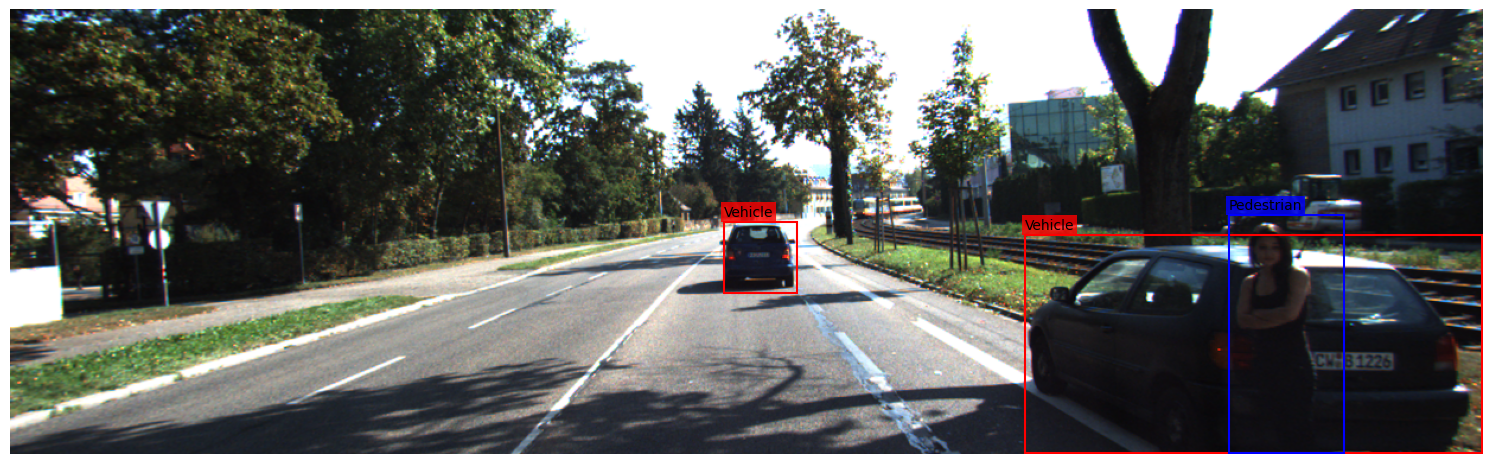

In [88]:
dataset = KittiDetectionDataset(base_dataset)

random_int = random.randint(0, 7480)
img, target = dataset[random_int]

img = img.permute(1, 2, 0)

fig, ax = plt.subplots(figsize=(19,9))
ax.imshow(img)
ax.axis("Off")

color_map = {
    "Vehicle": "red",
    "Pedestrian": "blue",
    "Cyclist": "green",
}

for box, label in zip(target["boxes"], target["labels"]):
    left, top, right, bottom = box.numpy()

    width = right - left
    height = bottom - top

    label = label.item()
    class_name = dataset.id_to_name[label]
    box_color = color_map.get(class_name, "white")
    
    rectangle = Rectangle(
        (left, top),
        width,
        height,
        fill=False,
        color=box_color,
        linewidth=1.5
    )

    ax.add_patch(rectangle)

    ax.text(
        left,
        top - 5,
        class_name,
        fontsize=10,
        color="black",
        bbox={
            "facecolor": box_color,
            "alpha": 0.8,
            "edgecolor": "none",
            "pad": 2
        }
    )

In [89]:
def collate_fn(batch):
    return tuple(zip(*batch))

dataloader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn
)

In [90]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)

In [ ]:
num_of_epochs = 1

for epoch in range(num_of_epochs):
    model.train()

    for batch_idx, (images, targets) in enumerate(dataloader):
        images = [image.to(device) for image in images]
        targets = [
            {
                key: value.to(device) if torch.is_tensor(value) else value
                for key, value in target.items()
            }
            for target in targets
        ]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch_idx % 10 == 0:
            print(f"Batch {batch_idx}, loss: {loss.item():.4f}")